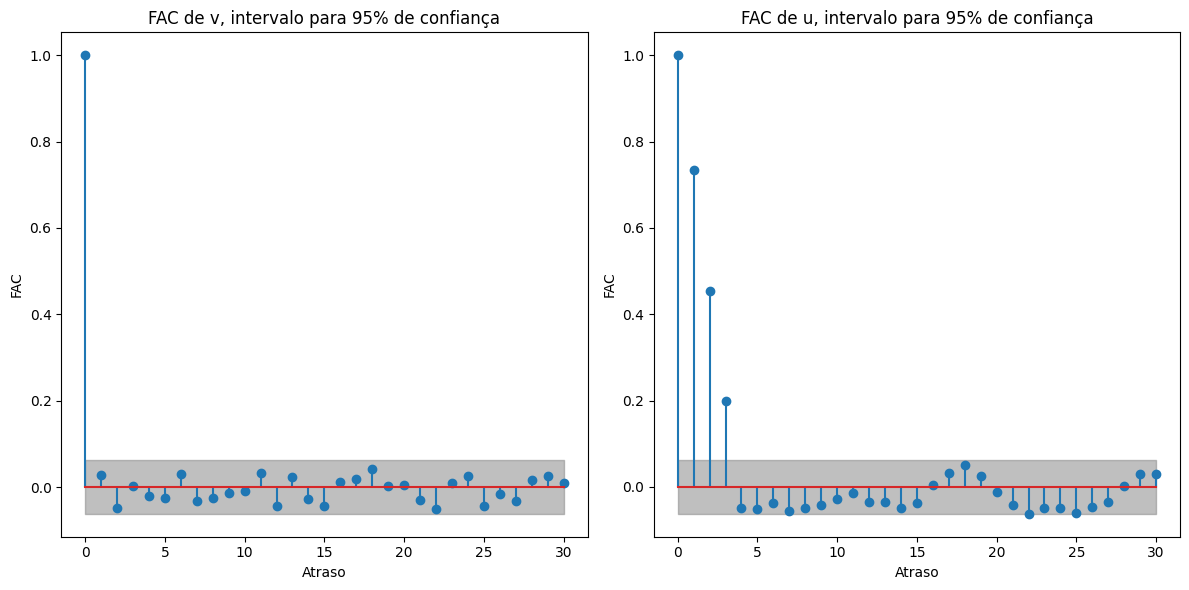

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, ccf, acovf, ccovf

# Define the signal u[k] = 0.9v[k-1] + 0.8v[k-2] + 0.7v[k-3] + v[k]
def u_func(k, v):
    return 0.9 * v[k-1] + 0.8 * v[k-2] + 0.7 * v[k-3] + v[k]

n_samples = 1000

# Initialize the input white noise
v = np.random.normal(0, 1, n_samples)

# Initialize the signal
u_signal = np.zeros(n_samples)

# Compute the signal u
for k in range(3, n_samples):
    u_signal[k] = u_func(k, v)

# Compute ACF for both v and u_signal
acf_v = acf(v)
acf_u = acf(u_signal)

# Compute the 95% confidence intervals
conf_int_v = 1.96 / np.sqrt(n_samples)
conf_int_u = 1.96 / np.sqrt(n_samples)

# Plot ACF and confidence intervals
plt.figure(figsize=(12, 6))

# ACF for v
plt.subplot(1, 2, 1)
plt.stem(acf_v)
plt.fill_between(np.arange(len(acf_v)), -conf_int_v, conf_int_v, color='gray', alpha=0.5)
plt.title('FAC de v, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

# ACF for u_signal
plt.subplot(1, 2, 2)
plt.stem(acf_u)
plt.fill_between(np.arange(len(acf_u)), -conf_int_u, conf_int_u, color='gray', alpha=0.5)
plt.title('FAC de u, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

plt.tight_layout()
plt.show()

A FAC de `v` condiz com o esperado, valor estatisticamente significante somente para $\tau=0$. Esta curca é característica de sinais brancos, para os quais `v[k]` não é função alguma de `v[k-1]`. Para `u`, a FAC também é coerente com a expressão matemárica. Apesar de `u[k]` não ser função de `u[k-1]`, dois de seus três termos tomam valores comuns de `u`:

\begin{align*}
u[k-1] = &0.9v[k-2] + 0.8v[k-3] + 0.7[k-4] + v[k-1] \\
u[k] = 0.9v[k-1] + &0.8v[k-2] + 0.7v[k-3] + v[k]
\end{align*}

Assim, mesmo que `u[k]` não seja efeito de `u[k-1]`, estes compartilham parte da causa, o que explica o decaimento suave da função de auto correlação.

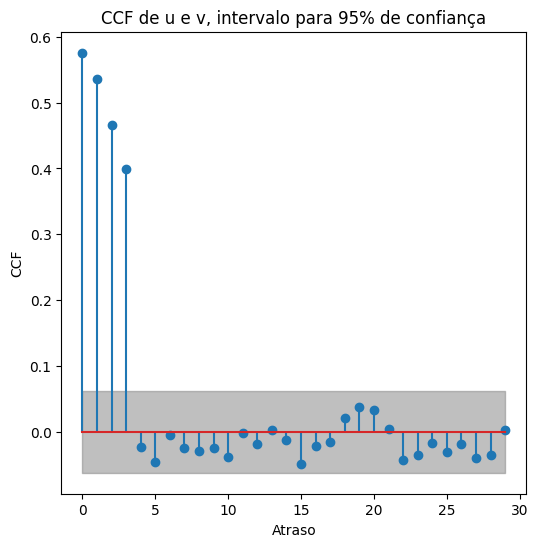

In [38]:
ccf_uv = ccf(u_signal, v, nlags=30)

# Compute the 95% confidence intervals
conf_int_uv = 1.96 / np.sqrt(n_samples)

# Plot CCF and confidence intervals
plt.figure(figsize=(6, 6))
plt.stem(ccf_uv)
plt.fill_between(np.arange(len(ccf_uv)), -conf_int_uv, conf_int_uv, color='gray', alpha=0.5)
plt.title('CCF de u e v, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

Já neste caso, a correlação alta para os primeiros intervalos se dá pelo fato de `u` ser função de `v`. Novamente, o decaimento suavizado nos primeiros atrasos decorre do comportamento passa baixas do sinal, definido por três valores consecultivos de `v`. É interessante notar que o decaimento repentino na correlação após $\tau = 3$ é coerente com a definição do sinal: como não há recursividade neste sistema, não é esperada correlação entre `u[k]` e `u[k-4]`.

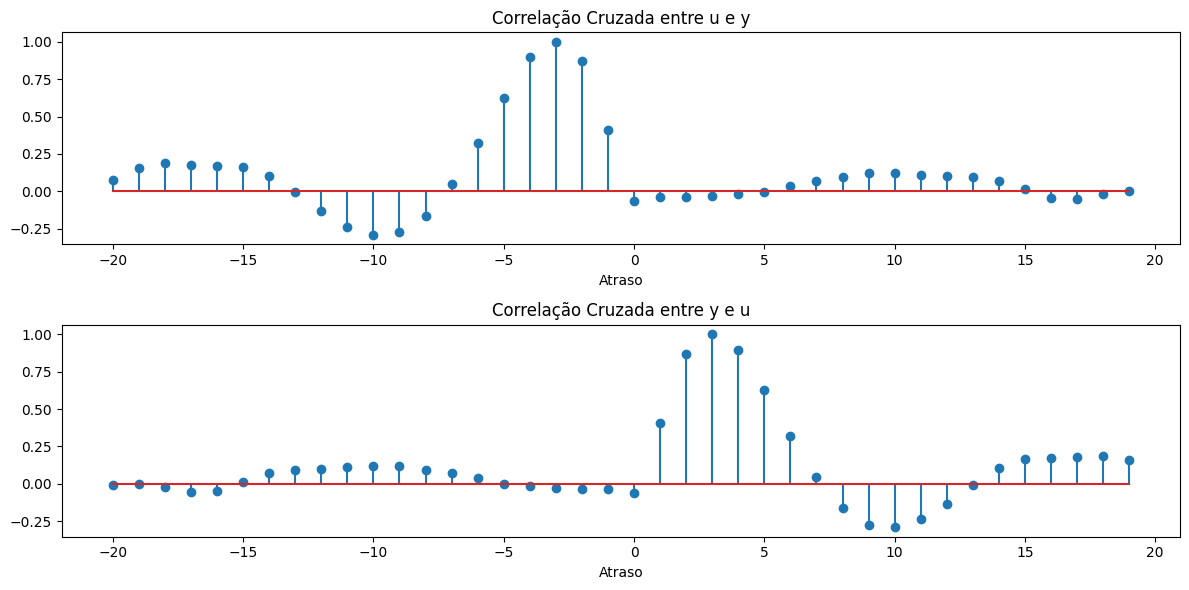

In [39]:
import scipy.signal as signal

# Define the transfer function H(z) = (z + 0.5) / (z^2 - 1.5z + 0.7)
num = [1, 0.5]
den = [1, -1.5, 0.7]
Ts = 1 # 1 second

# Define the input signal
u = np.random.uniform(-1, 1, n_samples)

# Simulate the system's response to u
t, y = signal.dlsim((num, den, Ts), u)
y = y.flatten()  # Flatten the output to 1D array

# Compute the CCF in both ways
ccf_uy = signal.correlate(u, y)
ccf_yu = signal.correlate(y, u)

# Normalize the CCFs
ccf_uy /= np.max(np.abs(ccf_uy))
ccf_yu /= np.max(np.abs(ccf_yu))

# Create lag vector for the full cross-correlation result
n = len(u)
lags = np.arange(-n + 1, n)

# Set plot interval
interval = (len(lags)//2)-20, (len(lags)//2)+20

# Plot the CCFs
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.title('Correlação Cruzada entre u e y')
plt.stem(lags[interval[0]:interval[1]], ccf_uy[interval[0]:interval[1]])  # Centered around zero lag
plt.xlabel('Atraso')

plt.subplot(2, 1, 2)
plt.title('Correlação Cruzada entre y e u')
plt.stem(lags[interval[0]:interval[1]], ccf_yu[interval[0]:interval[1]])  # Centered around zero lag
plt.xlabel('Atraso')

plt.tight_layout()
plt.show()


As curvas traçadas indicam que, quando a ordem dos parâmetros na chamada da função é `saída, entrada`, a correlação é mais significativa para atrasos positivos.

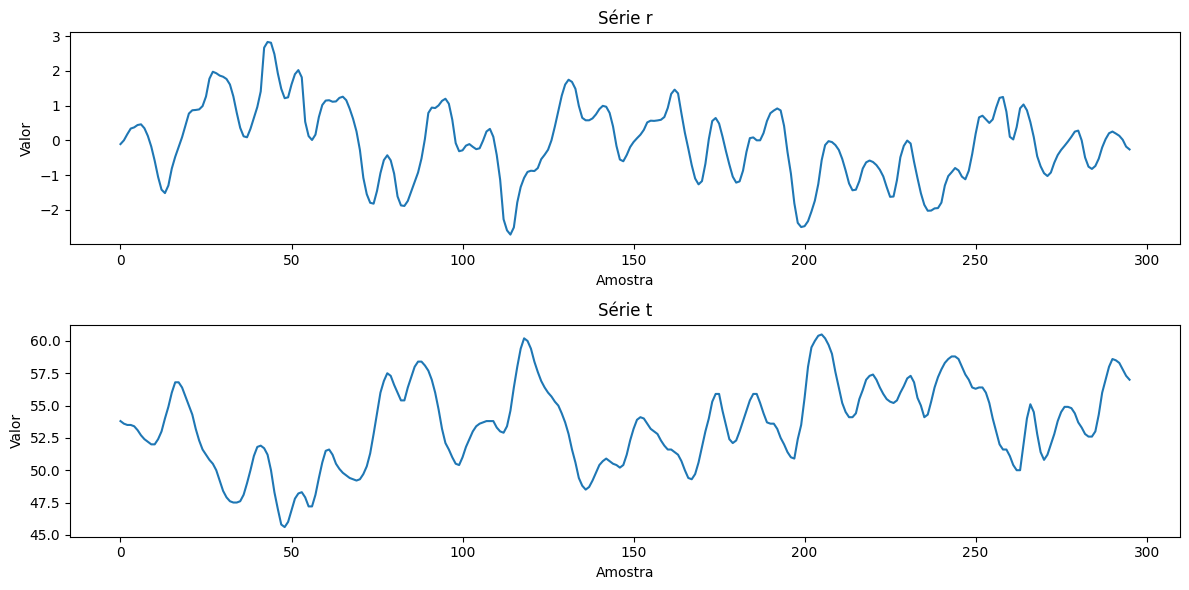

In [40]:
# Load the two-column data file into arrays
box = np.loadtxt('boxjenk.dat')
r, t = box[:, 0], box[:, 1]

# Plot the raw data
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(r)
plt.title('Série r')
plt.xlabel('Amostra')
plt.ylabel('Valor')
plt.subplot(2, 1, 2)
plt.plot(t)
plt.title('Série t')
plt.xlabel('Amostra')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()

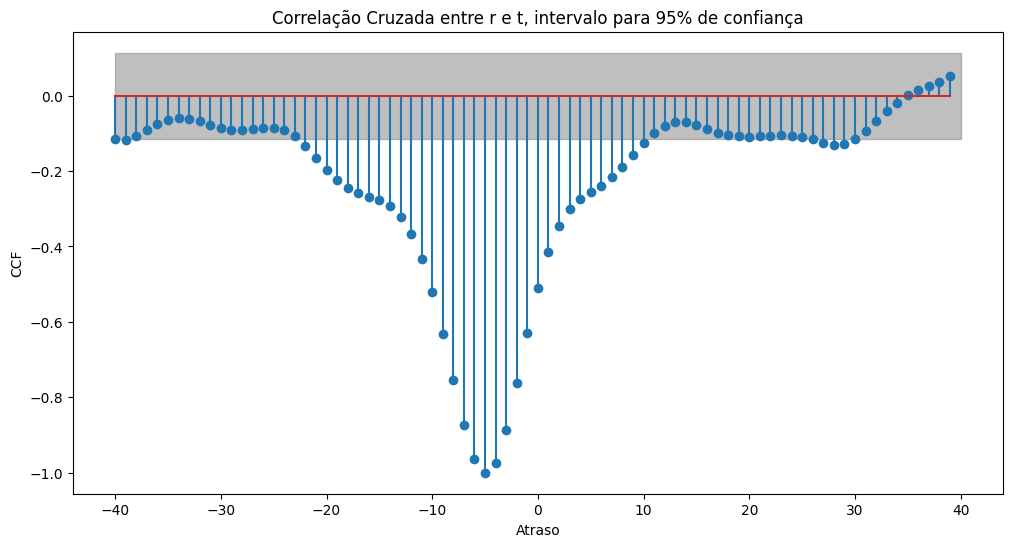

In [43]:
# Center the data by removing the mean
r, t = r - np.mean(r), t - np.mean(t)

# Compute CCF between r and t
ccf_rt = signal.correlate(r, t)

# Compute the 95% confidence intervals
conf_int_rt = 1.96 / np.sqrt(len(r))

# Normalize the CCF
ccf_rt /= np.max(np.abs(ccf_rt))

# Create lag vector for the full cross-correlation result
n = len(r)
lags = np.arange(-n + 1, n)

# Set plot interval
interval = (len(lags)//2)-40, (len(lags)//2)+40

# Plot the CCF with confidence intervals
plt.figure(figsize=(12, 6))
plt.stem(lags[interval[0]:interval[1]], ccf_rt[interval[0]:interval[1]])  # Centered around zero lag
plt.fill_between(np.arange(-40, 41), -conf_int_rt, conf_int_rt, color='gray', alpha=0.5)
plt.title('Correlação Cruzada entre r e t, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

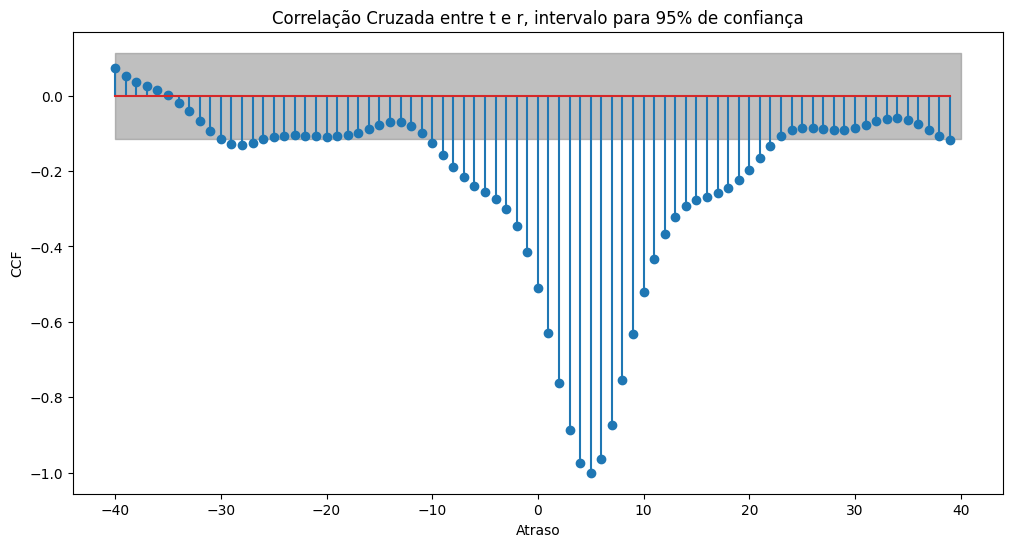

In [44]:
# Compute the CCF between t and r
ccf_tr = signal.correlate(t, r)

# Normalize the CCF
ccf_tr /= np.max(np.abs(ccf_tr))

# Plot the CCF with confidence intervals
plt.figure(figsize=(12, 6))
plt.stem(lags[interval[0]:interval[1]], ccf_tr[interval[0]:interval[1]])  # Centered around zero lag
plt.fill_between(np.arange(-40, 41), -conf_int_rt, conf_int_rt, color='gray', alpha=0.5)
plt.title('Correlação Cruzada entre t e r, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

As curvas indicam que `t` e `r` são, respectivamente, saída e entrada.